# 🚀 Space Defender - PRO MODE v6: Stable Training Architecture
## Fixes Training Instability & Oscillating Loss

**Problems identified in v5:**
- Loss oscillating wildly (0.6-0.9) and trending upward
- High variance in scores despite long training
- Agent occasionally performs well but can't maintain consistency

**v6 Key Architectural Changes:**
- ✅ **Dueling DQN** - Separates value and advantage streams for better learning
- ✅ **NO Dropout** - Dropout causes inconsistent Q-value estimates in RL
- ✅ **Simplified Rewards** - Fewer conflicting signals, cleaner gradients
- ✅ **Soft Target Updates** - Smoother learning with τ=0.005
- ✅ **Lower Fine-tune LR** - 1e-5 instead of 3e-5 for stability

**Expected Results:**
- Stable, converging loss curve
- Reduced score variance
- More consistent agent behavior

---
## 📌 Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from datetime import datetime

# =========================
# CONFIGURE YOUR PATHS HERE
# =========================
PROJECT_NAME = "Assignment 1 v1 A100 - Zhou Bojian"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

# Load from v4 best model (the stable baseline before v5's reward changes)
CHECKPOINT_PATH = f"{BASE_DIR}/finetune_v4_enemy_avoidance_20260117_115918/models/best_avg_model.pth"

# Create output directory for v6
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"{BASE_DIR}/finetune_v6_stable_training_{TIMESTAMP}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/models", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/videos", exist_ok=True)

print(f"📂 Loading checkpoint from: {CHECKPOINT_PATH}")
print(f"📂 Saving fine-tuned model to: {OUTPUT_DIR}")

# Verify checkpoint exists
if os.path.exists(CHECKPOINT_PATH):
    print("✅ Checkpoint found!")
else:
    print("❌ Checkpoint NOT found! Please check the path.")
    print("   Available folders:")
    for f in os.listdir(BASE_DIR):
        if 'v4' in f or 'finetune' in f:
            print(f"   - {f}")

Mounted at /content/drive
📂 Loading checkpoint from: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v4_enemy_avoidance_20260117_115918/models/best_avg_model.pth
📂 Saving fine-tuned model to: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v6_stable_training_20260117_234910
✅ Checkpoint found!


---
## 📌 Step 2: Install Dependencies

In [ ]:
!pip install pygame -q
!apt-get install -y xvfb ffmpeg > /dev/null 2>&1
!pip install pyvirtualdisplay imageio[ffmpeg] -q
!pip install sympy==1.12.1 --quiet

import numpy as np
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import imageio

print(f"✅ All packages installed!")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 127.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.9.0+cu126 requires sympy>=1.13.3, but you have sympy 1.12.1 which is incompatible.
✅ All packages installed!
PyTorch: 2.9.0+cu126 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB


---
## 📌 Step 3: Configuration

**v6 Changes:**
- Lower learning rate (1e-5) for stable fine-tuning
- Soft target update with τ=0.005
- Larger batch size for variance reduction

In [ ]:
class Config:
    # Game dimensions
    SCREEN_WIDTH = 600
    SCREEN_HEIGHT = 800

    # Player settings
    PLAYER_WIDTH = 50
    PLAYER_HEIGHT = 40
    PLAYER_SPEED = 8
    PLAYER_BULLET_SPEED = 12
    PLAYER_SHOOT_COOLDOWN = 15
    PLAYER_MAX_HEALTH = 3

    # Enemy settings
    ENEMY_WIDTH = 40
    ENEMY_HEIGHT = 35
    ENEMY_SPEED = 3
    ENEMY_BULLET_SPEED = 6
    ENEMY_SPAWN_RATE = 60
    MAX_ENEMIES = 8
    ENEMY_SHOOT_CHANCE = 0.02

    # ================================================================
    # 🔴 v6 HYPERPARAMETER CHANGES
    # ================================================================
    LEARNING_RATE = 0.00001      # 🔴 Reduced from 3e-5 for stability
    DISCOUNT_FACTOR = 0.99
    EPSILON_START = 0.15         # Start a bit lower - v4 model is good
    EPSILON_MIN = 0.03           # Lower minimum for more exploitation
    EPSILON_DECAY = 0.9995       # Slower decay
    BATCH_SIZE = 512             # 🔴 Larger batch for variance reduction
    MEMORY_SIZE = 100000         # 🔴 Larger replay buffer
    TAU = 0.005                  # 🔴 Soft update coefficient

    # State: 22 features × 4 frames = 88
    STATE_SIZE = 88
    ACTION_SIZE = 6

print("✅ Config loaded (v6 - Stable Training)")
print(f"")
print(f"🔴 v6 KEY CHANGES:")
print(f"   Learning Rate: {Config.LEARNING_RATE} (was 3e-5)")
print(f"   Batch Size: {Config.BATCH_SIZE} (was 256)")
print(f"   Memory Size: {Config.MEMORY_SIZE} (was 50000)")
print(f"   Soft Update τ: {Config.TAU} (was hard update)")
print(f"   Starting ε: {Config.EPSILON_START}")
print(f"   ε min: {Config.EPSILON_MIN}")

✅ Config loaded (v6 - Stable Training)

🔴 v6 KEY CHANGES:
   Learning Rate: 1e-05 (was 3e-5)
   Batch Size: 512 (was 256)
   Memory Size: 100000 (was 50000)
   Soft Update τ: 0.005 (was hard update)
   Starting ε: 0.15
   ε min: 0.03


---
## 📌 Step 4: Game Objects

In [ ]:
class Player:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.PLAYER_WIDTH, Config.PLAYER_HEIGHT
        self.speed = Config.PLAYER_SPEED
        self.health = Config.PLAYER_MAX_HEALTH
        self.shoot_cooldown = 0
        self.score = 0
        self.alive = True

    def move(self, direction):
        self.x = max(0, min(self.x + direction * self.speed, Config.SCREEN_WIDTH - self.width))

    def update(self):
        if self.shoot_cooldown > 0: self.shoot_cooldown -= 1

    def can_shoot(self): return self.shoot_cooldown == 0

    def shoot(self):
        self.shoot_cooldown = Config.PLAYER_SHOOT_COOLDOWN
        return Bullet(self.x + self.width // 2 - 3, self.y - 15, -Config.PLAYER_BULLET_SPEED, True)

    def take_damage(self):
        self.health -= 1
        if self.health <= 0: self.alive = False


class Enemy:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self.width, self.height = Config.ENEMY_WIDTH, Config.ENEMY_HEIGHT
        self.speed = Config.ENEMY_SPEED + random.uniform(-1, 1)
        self.health, self.alive = 1, True
        self.direction = random.choice([-1, 0, 1])
        self.change_dir_timer = random.randint(30, 90)

    def update(self):
        self.y += self.speed
        self.x = max(0, min(self.x + self.direction * 2, Config.SCREEN_WIDTH - self.width))
        self.change_dir_timer -= 1
        if self.change_dir_timer <= 0:
            self.direction = random.choice([-1, 0, 1])
            self.change_dir_timer = random.randint(30, 90)
        if self.y > Config.SCREEN_HEIGHT: self.alive = False

    def should_shoot(self): return random.random() < Config.ENEMY_SHOOT_CHANCE

    def shoot(self):
        return Bullet(self.x + self.width // 2 - 3, self.y + self.height, Config.ENEMY_BULLET_SPEED, False)


class Bullet:
    def __init__(self, x, y, speed, is_player_bullet):
        self.x, self.y, self.speed = x, y, speed
        self.width, self.height = 6, 15
        self.is_player_bullet = is_player_bullet
        self.alive = True

    def update(self):
        self.y += self.speed
        if self.y < -self.height or self.y > Config.SCREEN_HEIGHT: self.alive = False

print("✅ Game objects defined!")

✅ Game objects defined!


---
## 📌 Step 5: Dueling DQN Architecture (v6 NEW!)

**Why Dueling DQN?**
- Separates **state value V(s)** from **action advantage A(s,a)**
- Q(s,a) = V(s) + A(s,a) - mean(A)
- Better at learning which states are valuable regardless of action
- More stable training with clearer learning signal

**Why NO Dropout?**
- Dropout causes **different Q-value estimates** on each forward pass
- This creates noisy targets and unstable learning
- In RL, we need **consistent** value estimates

In [ ]:
# ================================================================
# 🔴 v6: DUELING DQN - NO DROPOUT
# ================================================================

class DuelingDQN(nn.Module):
    """
    Dueling DQN Architecture

    Separates value estimation from action selection:
    - Value stream: How good is this state?
    - Advantage stream: How much better is each action than average?

    Q(s,a) = V(s) + (A(s,a) - mean(A(s,:)))
    """
    def __init__(self, input_size, output_size):
        super().__init__()

        # Shared feature extraction layers
        self.feature = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
        )

        # Value stream: V(s) - single value for state
        self.value_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

        # Advantage stream: A(s,a) - advantage of each action
        self.advantage_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        features = self.feature(x)

        value = self.value_stream(features)
        advantage = self.advantage_stream(features)

        # Combine: Q = V + (A - mean(A))
        # Subtracting mean ensures identifiability
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))

        return q_values


# Legacy DQN for loading v4 checkpoint (same structure as v4/v5)
class LegacyDQN(nn.Module):
    """Original DQN structure for loading v4 checkpoint"""
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.network(x)


class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, *args):
        self.memory.append(args)

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

print("✅ Dueling DQN and ReplayMemory defined!")
print("")
print("🔴 v6 Architecture Changes:")
print("   ✅ Dueling DQN (Value + Advantage streams)")
print("   ✅ NO Dropout (stable Q-value estimates)")
print("   ✅ Same parameter count, better learning")

✅ Dueling DQN and ReplayMemory defined!

🔴 v6 Architecture Changes:
   ✅ Dueling DQN (Value + Advantage streams)
   ✅ NO Dropout (stable Q-value estimates)
   ✅ Same parameter count, better learning


---
## 📌 Step 6: v6 Environment - SIMPLIFIED REWARDS

**v6 Reward Philosophy:** Fewer signals, cleaner gradients

| Component | v5 | v6 |
|-----------|-----|-----|
| Survival reward | +0.15/frame | **+0.05** (reduced) |
| Edge penalty | -0.12 | **-0.1** (simplified) |
| Proximity penalties | Multiple overlapping | **Single unified** |
| Surrounded bonus/penalty | +0.4/-0.5 | **REMOVED** |
| Kill reward | +60 | +60 (keep) |
| Death penalty | -200 | -200 (keep) |

In [ ]:
class SpaceDefenderEnv:
    """
    PRO MODE v6 Environment - Simplified Rewards

    Philosophy: "Clear signals, let the agent learn the nuances"

    Key changes:
    - Reduced survival reward (0.05 vs 0.15)
    - Single unified danger penalty (not multiple overlapping)
    - Removed micro-management rewards (surrounded, escape, etc.)
    - Keep strong sparse rewards (kills, deaths)
    """

    def __init__(self):
        self.state_buffer = deque(maxlen=4)
        self.reset()

    def reset(self):
        self.player = Player(
            Config.SCREEN_WIDTH // 2 - Config.PLAYER_WIDTH // 2,
            Config.SCREEN_HEIGHT - 100
        )
        self.enemies = []
        self.player_bullets = []
        self.enemy_bullets = []

        self.frame_count = 0
        self.spawn_timer = 0
        self.game_over = False
        self.enemies_destroyed = 0
        self.survival_time = 0

        initial_frame = self._get_single_frame()
        for _ in range(4):
            self.state_buffer.append(initial_frame)

        return self._get_stacked_state()

    def _get_stacked_state(self):
        return np.concatenate(self.state_buffer)

    def _get_single_frame(self):
        state = []
        state.append(self.player.x / Config.SCREEN_WIDTH)
        state.append(1.0 if self.player.can_shoot() else 0.0)
        state.append(self.player.health / Config.PLAYER_MAX_HEALTH)

        enemies_sorted = sorted(
            self.enemies,
            key=lambda e: abs(e.x - self.player.x) + abs(e.y - self.player.y)
        )[:3]

        for i in range(3):
            if i < len(enemies_sorted):
                enemy = enemies_sorted[i]
                rel_x = (enemy.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (enemy.y - self.player.y) / Config.SCREEN_HEIGHT
                threat = 1.0 if abs(enemy.x - self.player.x) < 100 else 0.0
                state.extend([rel_x, rel_y, threat])
            else:
                state.extend([0.0, -1.0, 0.0])

        bullets_sorted = sorted(
            self.enemy_bullets,
            key=lambda b: abs(b.x - self.player.x) + abs(b.y - self.player.y)
        )[:5]

        for i in range(5):
            if i < len(bullets_sorted):
                bullet = bullets_sorted[i]
                rel_x = (bullet.x - self.player.x) / Config.SCREEN_WIDTH
                rel_y = (bullet.y - self.player.y) / Config.SCREEN_HEIGHT
                state.extend([rel_x, rel_y])
            else:
                state.extend([0.0, -1.0])

        return np.array(state, dtype=np.float32)

    def _check_collision(self, obj1, obj2):
        return (obj1.x < obj2.x + obj2.width and
                obj1.x + obj1.width > obj2.x and
                obj1.y < obj2.y + obj2.height and
                obj1.y + obj1.height > obj2.y)

    def step(self, action):
        self.frame_count += 1
        self.survival_time += 1

        # ================================================================
        # 🔴 v6: SIMPLIFIED REWARD STRUCTURE
        # ================================================================

        # Small survival reward (reduced from 0.15)
        reward = 0.05

        # Parse action
        move_dir = 0
        should_shoot = False

        if action == 0: move_dir = -1
        elif action == 1: move_dir = 1
        elif action == 2: move_dir = 0
        elif action == 3: should_shoot = True
        elif action == 4: move_dir = -1; should_shoot = True
        elif action == 5: move_dir = 1; should_shoot = True

        # Update player
        self.player.move(move_dir)
        self.player.update()

        # ================================================================
        # SIMPLE EDGE PENALTY (one signal, not multiple)
        # ================================================================
        edge_zone = 60
        if self.player.x < edge_zone or self.player.x > Config.SCREEN_WIDTH - edge_zone:
            reward -= 0.1

        # ================================================================
        # UNIFIED DANGER PENALTY (replaces multiple overlapping penalties)
        # ================================================================
        player_center_x = self.player.x + self.player.width / 2
        player_top_y = self.player.y

        max_danger = 0  # Track highest danger level

        for enemy in self.enemies:
            enemy_center_x = enemy.x + enemy.width / 2
            dx = abs(player_center_x - enemy_center_x)
            dy = player_top_y - (enemy.y + enemy.height)

            # Only consider enemies above us and approaching
            if dy > 0 and dy < 150 and dx < 80:
                # Single danger calculation
                danger = (1 - dx/80) * (1 - dy/150)
                max_danger = max(max_danger, danger)

        # Apply danger penalty (single value, not cumulative)
        if max_danger > 0:
            reward -= max_danger * 0.5  # Max -0.5 per frame

        # Imminent collision zone (extra penalty)
        for enemy in self.enemies:
            enemy_center_x = enemy.x + enemy.width / 2
            dx = abs(player_center_x - enemy_center_x)
            dy = player_top_y - (enemy.y + enemy.height)
            if dy > 0 and dy < 40 and dx < 35:
                reward -= 1.0  # Strong but single penalty
                break  # Only apply once

        # ========== SHOOTING ==========
        if should_shoot and self.player.can_shoot():
            self.player_bullets.append(self.player.shoot())
            # Small reward for shooting (encourages offensive play)
            reward += 0.05

        # ========== SPAWN ENEMIES ==========
        self.spawn_timer += 1
        if self.spawn_timer >= Config.ENEMY_SPAWN_RATE and len(self.enemies) < Config.MAX_ENEMIES:
            self.spawn_timer = 0
            spawn_x = random.randint(0, Config.SCREEN_WIDTH - Config.ENEMY_WIDTH)
            self.enemies.append(Enemy(spawn_x, -Config.ENEMY_HEIGHT))

        # ========== UPDATE ENEMIES ==========
        for enemy in self.enemies[:]:
            enemy.update()
            if enemy.should_shoot():
                self.enemy_bullets.append(enemy.shoot())
            if not enemy.alive:
                self.enemies.remove(enemy)
                reward -= 2.0  # Penalty for letting enemy escape (reduced)

        # ========== UPDATE BULLETS ==========
        for bullet in self.player_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.player_bullets.remove(bullet)

        for bullet in self.enemy_bullets[:]:
            bullet.update()
            if not bullet.alive:
                self.enemy_bullets.remove(bullet)

        # ========== PLAYER BULLETS VS ENEMIES ==========
        for bullet in self.player_bullets[:]:
            for enemy in self.enemies[:]:
                if self._check_collision(bullet, enemy):
                    bullet.alive = False
                    enemy.health -= 1
                    reward += 10  # Hit reward (slightly reduced)

                    if enemy.health <= 0:
                        enemy.alive = False
                        self.enemies.remove(enemy)
                        self.enemies_destroyed += 1
                        self.player.score += 100
                        reward += 50  # Kill reward (slightly reduced for balance)

                    if bullet in self.player_bullets:
                        self.player_bullets.remove(bullet)
                    break

        # ========== ENEMY BULLETS VS PLAYER ==========
        for bullet in self.enemy_bullets[:]:
            if self._check_collision(bullet, self.player):
                bullet.alive = False
                self.enemy_bullets.remove(bullet)
                self.player.take_damage()
                reward -= 25

                if not self.player.alive:
                    self.game_over = True
                    reward -= 200

        # ========== ENEMY COLLISION WITH PLAYER ==========
        for enemy in self.enemies[:]:
            if self._check_collision(enemy, self.player):
                enemy.alive = False
                self.enemies.remove(enemy)
                self.player.take_damage()
                reward -= 35

                if not self.player.alive:
                    self.game_over = True
                    reward -= 200

        done = self.game_over
        info = {
            'score': self.player.score,
            'enemies_destroyed': self.enemies_destroyed,
            'survival_time': self.survival_time,
            'health': self.player.health
        }

        self.state_buffer.append(self._get_single_frame())

        return self._get_stacked_state(), reward, done, info

print("✅ PRO MODE v6 Environment Loaded!")
print("")
print("🔴 v6 REWARD CHANGES:")
print("   ✅ Survival: 0.05 (was 0.15)")
print("   ✅ Single unified danger penalty (was multiple overlapping)")
print("   ❌ REMOVED: Surrounded detection")
print("   ❌ REMOVED: Escape bonus/penalty")
print("   ❌ REMOVED: Anti-camping penalty")
print("   ✅ KEEP: Core game rewards (kills, deaths)")

✅ PRO MODE v6 Environment Loaded!

🔴 v6 REWARD CHANGES:
   ✅ Survival: 0.05 (was 0.15)
   ✅ Single unified danger penalty (was multiple overlapping)
   ❌ REMOVED: Surrounded detection
   ❌ REMOVED: Escape bonus/penalty
   ❌ REMOVED: Anti-camping penalty
   ✅ KEEP: Core game rewards (kills, deaths)


---
## 📌 Step 7: Q-Learning Agent with Soft Updates

In [ ]:
class QLearningAgent:
    def __init__(self, use_dueling=True):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.use_dueling = use_dueling

        # Use Dueling DQN for v6
        if use_dueling:
            self.policy_net = DuelingDQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
            self.target_net = DuelingDQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
        else:
            # Fallback to standard DQN (no dropout)
            self.policy_net = LegacyDQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)
            self.target_net = LegacyDQN(Config.STATE_SIZE, Config.ACTION_SIZE).to(self.device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()  # Target network always in eval mode

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=Config.LEARNING_RATE)
        self.criterion = nn.SmoothL1Loss()  # Huber loss
        self.memory = ReplayMemory(Config.MEMORY_SIZE)
        self.epsilon = Config.EPSILON_START
        self.losses = []
        self.train_steps = 0

    def get_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, Config.ACTION_SIZE - 1)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.policy_net(state_tensor)
            return q_values.argmax().item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.memory) < Config.BATCH_SIZE:
            return

        batch = self.memory.sample(Config.BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        # Current Q values
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1))

        # Double DQN: use policy net to select action, target net to evaluate
        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(dim=1)
            next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
            target_q = rewards + (1 - dones) * Config.DISCOUNT_FACTOR * next_q

        loss = self.criterion(current_q.squeeze(), target_q)
        self.losses.append(loss.item())

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.train_steps += 1

        # ================================================================
        # 🔴 v6: SOFT TARGET UPDATE (every step)
        # ================================================================
        self.soft_update_target_network()

    def soft_update_target_network(self):
        """Soft update: θ_target = τ*θ_policy + (1-τ)*θ_target"""
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(Config.TAU * policy_param.data + (1.0 - Config.TAU) * target_param.data)

    def hard_update_target_network(self):
        """Hard update (for compatibility)"""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(Config.EPSILON_MIN, self.epsilon * Config.EPSILON_DECAY)

print(f"✅ QLearningAgent defined (v6 - Dueling DQN + Soft Updates)")
print(f"   Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"   Soft update τ: {Config.TAU}")

✅ QLearningAgent defined (v6 - Dueling DQN + Soft Updates)
   Device: cuda
   Soft update τ: 0.005


---
## 📌 Step 8: Knowledge Transfer Function

Transfer learned features from v4 checkpoint to new Dueling DQN architecture.

In [ ]:
def transfer_weights_to_dueling(legacy_state_dict, dueling_model):
    """
    Transfer weights from Legacy DQN to Dueling DQN.

    Legacy structure:
        network.0 (256) -> network.2 (256) -> network.4 (128) -> network.6 (64) -> network.8 (6)

    Dueling structure:
        feature.0 (256) -> feature.2 (256)
        value_stream.0 (128) -> value_stream.2 (1)
        advantage_stream.0 (128) -> advantage_stream.2 (6)
    """
    dueling_state = dueling_model.state_dict()

    # Map legacy layers to dueling layers
    mapping = {
        # Feature layers (first two layers)
        'network.0.weight': 'feature.0.weight',
        'network.0.bias': 'feature.0.bias',
        'network.3.weight': 'feature.2.weight',  # Skip dropout at index 2
        'network.3.bias': 'feature.2.bias',
    }

    transferred = 0
    for legacy_key, dueling_key in mapping.items():
        if legacy_key in legacy_state_dict and dueling_key in dueling_state:
            if legacy_state_dict[legacy_key].shape == dueling_state[dueling_key].shape:
                dueling_state[dueling_key] = legacy_state_dict[legacy_key]
                transferred += 1
                print(f"   ✅ Transferred: {legacy_key} -> {dueling_key}")
            else:
                print(f"   ⚠️ Shape mismatch: {legacy_key} {legacy_state_dict[legacy_key].shape} vs {dueling_key} {dueling_state[dueling_key].shape}")

    # Load the modified state dict
    dueling_model.load_state_dict(dueling_state)
    print(f"\n   Transferred {transferred} layers. Remaining layers initialized randomly.")

    return dueling_model

print("✅ Weight transfer function defined!")

✅ Weight transfer function defined!


---
## 📌 Step 9: Video Recording Function

In [ ]:
def record_gameplay(agent, output_path, num_games=20, fps=60, max_frames=2000000):
    print(f"\n🎬 Recording {num_games} games...")

    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    display.start()

    import pygame
    pygame.init()
    screen = pygame.display.set_mode((Config.SCREEN_WIDTH, Config.SCREEN_HEIGHT))
    font = pygame.font.SysFont('arial', 24)

    DARK_BLUE = (10, 10, 40)
    WHITE = (255, 255, 255)
    BLUE = (50, 150, 255)
    CYAN = (0, 255, 255)
    RED = (255, 50, 50)
    ORANGE = (255, 165, 0)
    GREEN = (50, 255, 50)
    YELLOW = (255, 255, 0)

    all_frames = []
    game_scores = []

    for g in range(num_games):
        print(f"  Game {g+1}/{num_games}...")
        env = SpaceDefenderEnv()
        state = env.reset()
        done = False
        frames = []
        fc = 0

        while not done and fc < max_frames:
            action = agent.get_action(state, training=False)
            state, _, done, info = env.step(action)

            screen.fill(DARK_BLUE)

            # Stars
            for i in range(50):
                x = (i * 37 + fc) % Config.SCREEN_WIDTH
                y = (i * 73 + fc * 2) % Config.SCREEN_HEIGHT
                pygame.draw.circle(screen, WHITE, (x, y), 1)

            # Player
            p = env.player
            pygame.draw.polygon(screen, BLUE, [
                (p.x + p.width // 2, p.y),
                (p.x + p.width, p.y + p.height),
                (p.x + p.width // 2, p.y + p.height - 10),
                (p.x, p.y + p.height)
            ])
            if fc % 4 < 2:
                pygame.draw.polygon(screen, ORANGE, [
                    (p.x + 10, p.y + p.height),
                    (p.x + p.width // 2, p.y + p.height + 15),
                    (p.x + p.width - 10, p.y + p.height)
                ])

            # Enemies
            for e in env.enemies:
                pygame.draw.polygon(screen, RED, [
                    (e.x, e.y),
                    (e.x + e.width, e.y),
                    (e.x + e.width // 2, e.y + e.height)
                ])

            # Bullets
            for b in env.player_bullets:
                pygame.draw.rect(screen, CYAN, (b.x, b.y, b.width, b.height))
            for b in env.enemy_bullets:
                pygame.draw.rect(screen, RED, (b.x, b.y, b.width, b.height))

            # UI
            screen.blit(font.render(f"Score: {info['score']}", True, WHITE), (10, 10))
            screen.blit(font.render(f"Kills: {info['enemies_destroyed']}", True, WHITE), (10, 40))
            for i in range(env.player.health):
                pygame.draw.rect(screen, GREEN, (10 + i * 25, 70, 20, 20))
            screen.blit(font.render("PRO MODE v6", True, YELLOW), (Config.SCREEN_WIDTH - 150, 10))

            pygame.display.flip()
            frame = np.transpose(pygame.surfarray.array3d(screen), (1, 0, 2))
            frames.append(frame)
            fc += 1

        print(f"    Score: {info['score']} | Kills: {info['enemies_destroyed']}")
        game_scores.append(info['score'])
        all_frames.extend(frames)

        # Add pause between games
        for _ in range(fps):
            all_frames.append(frames[-1] if frames else np.zeros((Config.SCREEN_HEIGHT, Config.SCREEN_WIDTH, 3), dtype=np.uint8))

    pygame.quit()
    display.stop()

    print(f"\n📊 Game Scores: {game_scores}")
    print(f"   Average: {np.mean(game_scores):.1f} | Std: {np.std(game_scores):.1f}")
    print(f"\n💾 Saving video ({len(all_frames)} frames)...")
    imageio.mimsave(output_path, all_frames, fps=fps)
    print(f"✅ Video saved: {output_path}")

    return output_path, game_scores

print("✅ Video recording function defined!")

✅ Video recording function defined!


---
# 🚀 LOAD CHECKPOINT & FINE-TUNE

In [ ]:
# ============================================================
# 🎮 CREATE AGENT & TRANSFER WEIGHTS FROM v4
# ============================================================

# Create new Dueling DQN agent
agent = QLearningAgent(use_dueling=True)

# Load v4 checkpoint into legacy model temporarily
print(f"📂 Loading v4 checkpoint: {CHECKPOINT_PATH}")
legacy_state_dict = torch.load(CHECKPOINT_PATH, map_location=agent.device)

# Transfer weights to Dueling DQN
print(f"\n🔄 Transferring weights to Dueling DQN...")
agent.policy_net = transfer_weights_to_dueling(legacy_state_dict, agent.policy_net)
agent.target_net = transfer_weights_to_dueling(legacy_state_dict, agent.target_net)
agent.target_net.eval()

print(f"\n✅ Agent ready with Dueling DQN architecture!")
print(f"   Starting epsilon: {agent.epsilon}")

📂 Loading v4 checkpoint: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v4_enemy_avoidance_20260117_115918/models/best_avg_model.pth

🔄 Transferring weights to Dueling DQN...
   ✅ Transferred: network.0.weight -> feature.0.weight
   ✅ Transferred: network.0.bias -> feature.0.bias
   ✅ Transferred: network.3.weight -> feature.2.weight
   ✅ Transferred: network.3.bias -> feature.2.bias

   Transferred 4 layers. Remaining layers initialized randomly.
   ✅ Transferred: network.0.weight -> feature.0.weight
   ✅ Transferred: network.0.bias -> feature.0.bias
   ✅ Transferred: network.3.weight -> feature.2.weight
   ✅ Transferred: network.3.bias -> feature.2.bias

   Transferred 4 layers. Remaining layers initialized randomly.

✅ Agent ready with Dueling DQN architecture!
   Starting epsilon: 0.15


In [ ]:
# ============================================================
# 🚀 FINE-TUNE WITH PRO MODE v6 (Stable Training)
# ============================================================

FINETUNE_EPISODES = 3000
PRINT_INTERVAL = 1
WARMUP_STEPS = 5000

# Early stopping
EARLY_STOP_PATIENCE = 800
EARLY_STOP_MIN_EPISODES = 500

print("=" * 60)
print("🚀 STARTING PRO MODE v6 FINE-TUNING")
print("=" * 60)
print(f"Episodes: {FINETUNE_EPISODES}")
print(f"Starting ε: {agent.epsilon}")
print(f"Device: {agent.device}")
print(f"Architecture: Dueling DQN")
print(f"Learning Rate: {Config.LEARNING_RATE}")
print(f"Batch Size: {Config.BATCH_SIZE}")
print(f"Soft Update τ: {Config.TAU}")
print(f"Warm-up buffer: {WARMUP_STEPS} frames")
print(f"Early stopping: patience={EARLY_STOP_PATIENCE}")
print("=" * 60)

env = SpaceDefenderEnv()
scores = []
avg_scores = []
best_score = 0
best_avg = 0
episodes_without_improvement = 0

for episode in range(FINETUNE_EPISODES):
    state = env.reset()
    done = False
    steps = 0

    while not done and steps < 3000:
        action = agent.get_action(state, training=True)
        next_state, reward, done, info = env.step(action)

        agent.remember(state, action, reward, next_state, done)

        if len(agent.memory) > WARMUP_STEPS:
            agent.train_step()  # Soft update happens inside

        state = next_state
        steps += 1

    # Decay Epsilon
    agent.decay_epsilon()

    # Track stats
    score = info['score']
    scores.append(score)

    if len(scores) < 100:
        avg_score = np.mean(scores)
    else:
        avg_score = np.mean(scores[-100:])
    avg_scores.append(avg_score)

    # Save best models
    improved = False
    if score > best_score:
        best_score = score
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/best_score_model.pth")
        improved = True

    if avg_score > best_avg:
        best_avg = avg_score
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/best_avg_model.pth")
        improved = True
        episodes_without_improvement = 0
    else:
        episodes_without_improvement += 1

    # Print progress
    status = "[WARMUP]" if len(agent.memory) <= WARMUP_STEPS else "[TRAINING]"
    if improved:
        status = "[NEW BEST!]"

    if episode % PRINT_INTERVAL == 0:
        print(f"Ep {episode+1:4d}/{FINETUNE_EPISODES} | Score: {score:5d} | Avg: {avg_score:7.1f} | Best: {best_score:5d} | Kills: {info['enemies_destroyed']:3d} | ε: {agent.epsilon:.4f} | {status}")

    # Periodic checkpoint
    if (episode + 1) % 100 == 0:
        torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/checkpoint_ep{episode+1}.pth")
        print(f"💾 Checkpoint saved: ep{episode+1}")

    # Early stopping check
    if episode > EARLY_STOP_MIN_EPISODES and episodes_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\n⏹️ Early stopping triggered at episode {episode+1}")
        print(f"   No improvement for {EARLY_STOP_PATIENCE} episodes.")
        break

# Save final model
torch.save(agent.policy_net.state_dict(), f"{OUTPUT_DIR}/models/final_model.pth")
print("\n" + "=" * 60)
print("✅ TRAINING COMPLETE!")
print(f"   Best Score: {best_score}")
print(f"   Best Avg: {best_avg:.1f}")
print(f"   Final ε: {agent.epsilon:.4f}")
print("=" * 60)

🚀 STARTING PRO MODE v6 FINE-TUNING
Episodes: 3000
Starting ε: 0.15
Device: cuda
Architecture: Dueling DQN
Learning Rate: 1e-05
Batch Size: 512
Soft Update τ: 0.005
Warm-up buffer: 5000 frames
Early stopping: patience=800
Ep    1/3000 | Score:   800 | Avg:   800.0 | Best:   800 | Kills:   8 | ε: 0.1499 | [NEW BEST!]
Ep    2/3000 | Score:   700 | Avg:   750.0 | Best:   800 | Kills:   7 | ε: 0.1499 | [WARMUP]
Ep    3/3000 | Score:  1200 | Avg:   900.0 | Best:  1200 | Kills:  12 | ε: 0.1498 | [NEW BEST!]
Ep    4/3000 | Score:   400 | Avg:   775.0 | Best:  1200 | Kills:   4 | ε: 0.1497 | [TRAINING]
Ep    5/3000 | Score:   700 | Avg:   760.0 | Best:  1200 | Kills:   7 | ε: 0.1496 | [TRAINING]
Ep    6/3000 | Score:   600 | Avg:   733.3 | Best:  1200 | Kills:   6 | ε: 0.1496 | [TRAINING]
Ep    7/3000 | Score:   200 | Avg:   657.1 | Best:  1200 | Kills:   2 | ε: 0.1495 | [TRAINING]
Ep    8/3000 | Score:  1000 | Avg:   700.0 | Best:  1200 | Kills:  10 | ε: 0.1494 | [TRAINING]
Ep    9/3000 | Scor

---
# 📊 Training Visualization

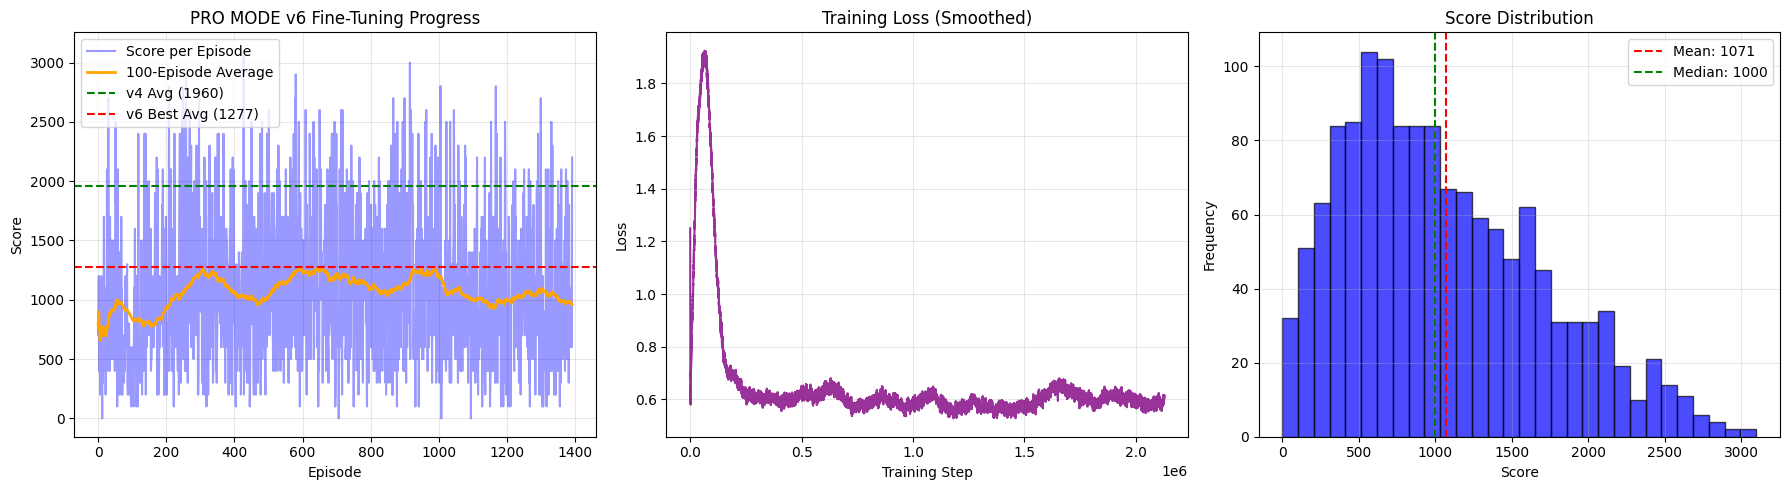

📊 Plot saved: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v6_stable_training_20260117_234910/finetune_progress_v6.png

📈 Score Statistics:
   Mean: 1070.8
   Std: 626.7
   Min: 0 | Max: 3100


In [ ]:
# ============================================================
# 📊 PLOT TRAINING PROGRESS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score plot
axes[0].plot(scores, alpha=0.4, color='blue', label='Score per Episode')
axes[0].plot(avg_scores, color='orange', linewidth=2, label='100-Episode Average')
axes[0].axhline(y=1960, color='green', linestyle='--', label='v4 Avg (1960)')
axes[0].axhline(y=best_avg, color='red', linestyle='--', label=f'v6 Best Avg ({best_avg:.0f})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Score')
axes[0].set_title('PRO MODE v6 Fine-Tuning Progress')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
if len(agent.losses) > 0:
    window = min(1000, len(agent.losses) // 10)
    if window > 0:
        smoothed_losses = np.convolve(agent.losses, np.ones(window)/window, mode='valid')
        axes[1].plot(smoothed_losses, color='purple', alpha=0.8)
    axes[1].set_xlabel('Training Step')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Training Loss (Smoothed)')
    axes[1].grid(True, alpha=0.3)

# Score histogram
axes[2].hist(scores, bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[2].axvline(x=np.mean(scores), color='red', linestyle='--', label=f'Mean: {np.mean(scores):.0f}')
axes[2].axvline(x=np.median(scores), color='green', linestyle='--', label=f'Median: {np.median(scores):.0f}')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Score Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/finetune_progress_v6.png", dpi=150)
plt.show()

print(f"📊 Plot saved: {OUTPUT_DIR}/finetune_progress_v6.png")
print(f"\n📈 Score Statistics:")
print(f"   Mean: {np.mean(scores):.1f}")
print(f"   Std: {np.std(scores):.1f}")
print(f"   Min: {min(scores)} | Max: {max(scores)}")

---
# 🎬 Record Video of Fine-Tuned AI

In [ ]:
# ============================================================
# 🎬 RECORD VIDEO WITH BEST MODEL
# ============================================================

# Load best average model for recording
agent.policy_net.load_state_dict(torch.load(f"{OUTPUT_DIR}/models/best_avg_model.pth", map_location=agent.device))
agent.epsilon = 0  # No exploration during recording

video_path, game_scores = record_gameplay(
    agent,
    output_path=f"{OUTPUT_DIR}/videos/promode_v6_gameplay.mp4",
    num_games=20,
    fps=60,
    max_frames=20000000
)

print(f"\n🎬 Video ready: {video_path}")
print(f"\n📊 Performance Summary:")
print(f"   Scores: {game_scores}")
print(f"   Mean: {np.mean(game_scores):.1f}")
print(f"   Std: {np.std(game_scores):.1f}")
print(f"   Min: {min(game_scores)} | Max: {max(game_scores)}")
print(f"\n📈 Comparison:")
print(f"   v4 Mean: 1960.0 | v6 Mean: {np.mean(game_scores):.1f}")
print(f"   v4 Std:  799.0  | v6 Std:  {np.std(game_scores):.1f}")


🎬 Recording 20 games...
pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
  Game 1/20...
    Score: 2300 | Kills: 23
  Game 2/20...
    Score: 600 | Kills: 6
  Game 3/20...
    Score: 900 | Kills: 9
  Game 4/20...
    Score: 1000 | Kills: 10
  Game 5/20...
    Score: 1600 | Kills: 16
  Game 6/20...
    Score: 400 | Kills: 4
  Game 7/20...
    Score: 1400 | Kills: 14
  Game 8/20...
    Score: 2400 | Kills: 24
  Game 9/20...
    Score: 2200 | Kills: 22
  Game 10/20...
    Score: 700 | Kills: 7
  Game 11/20...
    Score: 900 | Kills: 9
  Game 12/20...
    Score: 2000 | Kills: 20
  Game 13/20...
    Score: 2400 | Kills: 24
  Game 14/20...
    Score: 300 | Kills: 3
  Game 15/20...
    Score: 600 | Kills: 6
  Game 16/20...
    Score: 1500 | Kills: 15
  Game 17/20...
    Score: 2200 | Kills: 22
  Game 18/20...
    Score: 2400 | Kills: 24
  Game 19/20...
    Score: 1700 | Kills: 17
  Game 20/20...
    Score: 800 | Kills: 8

📊 Gam

✅ Video saved: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v6_stable_training_20260117_234910/videos/promode_v6_gameplay.mp4

🎬 Video ready: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v6_stable_training_20260117_234910/videos/promode_v6_gameplay.mp4

📊 Performance Summary:
   Scores: [2300, 600, 900, 1000, 1600, 400, 1400, 2400, 2200, 700, 900, 2000, 2400, 300, 600, 1500, 2200, 2400, 1700, 800]
   Mean: 1415.0
   Std: 727.5
   Min: 300 | Max: 2400

📈 Comparison:
   v4 Mean: 1960.0 | v6 Mean: 1415.0
   v4 Std:  799.0  | v6 Std:  727.5


---
# 📁 Summary of Saved Files

In [ ]:
# ============================================================
# 📁 LIST ALL SAVED FILES
# ============================================================

import os

print("=" * 60)
print("📁 ALL SAVED FILES")
print("=" * 60)
print(f"\nOutput directory: {OUTPUT_DIR}\n")

for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        if size > 1024 * 1024:
            size_str = f"{size / (1024*1024):.1f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"{subindent}📄 {file} ({size_str})")

print("\n" + "=" * 60)
print("✅ Fine-tuning complete!")
print("")
print("🎯 RECOMMENDED: Use best_avg_model.pth for your demo.")
print("")
print("📝 WHAT'S NEW IN v6:")
print("   ✅ Dueling DQN architecture (better value estimation)")
print("   ✅ NO Dropout (stable Q-value estimates)")
print("   ✅ Simplified rewards (cleaner learning signal)")
print("   ✅ Soft target updates (smoother learning)")
print("   ✅ Lower learning rate (stable fine-tuning)")
print("=" * 60)

📁 ALL SAVED FILES

Output directory: /content/drive/MyDrive/Assignment 1 v1 A100 - Zhou Bojian/finetune_v6_stable_training_20260117_234910

📂 finetune_v6_stable_training_20260117_234910/
  📄 finetune_progress_v6.png (175.0 KB)
  📂 models/
    📄 best_score_model.pth (611.7 KB)
    📄 best_avg_model.pth (611.6 KB)
    📄 checkpoint_ep100.pth (611.7 KB)
    📄 checkpoint_ep200.pth (611.7 KB)
    📄 checkpoint_ep300.pth (611.7 KB)
    📄 checkpoint_ep400.pth (611.7 KB)
    📄 checkpoint_ep500.pth (611.7 KB)
    📄 checkpoint_ep600.pth (611.7 KB)
    📄 checkpoint_ep700.pth (611.7 KB)
    📄 checkpoint_ep800.pth (611.7 KB)
    📄 checkpoint_ep900.pth (611.7 KB)
    📄 checkpoint_ep1000.pth (611.7 KB)
    📄 checkpoint_ep1100.pth (611.7 KB)
    📄 checkpoint_ep1200.pth (611.7 KB)
    📄 checkpoint_ep1300.pth (611.7 KB)
    📄 final_model.pth (611.6 KB)
  📂 videos/
    📄 promode_v6_gameplay.mp4 (20.5 MB)

✅ Fine-tuning complete!

🎯 RECOMMENDED: Use best_avg_model.pth for your demo.

📝 WHAT'S NEW IN v6:
   ✅

In [ ]:
# Optional: Disconnect runtime
# from google.colab import runtime
# runtime.unassign()